# TASK 2 — Unemployment Analysis with Python

## Introduction

#### Unemployment IS An Important Economic Indicator That Reflects The Condition Of The Labour Market And The Availability Of Employment Opportunities.

#### This Project Performs Exploratory Data Analysis On Unemployment Data From India to Identify Regional And Temporal Trends in Unemployment Rates.

#### The Analysis Focuses On Understanding Unemployment Patterns Across Different Regions and Examining The Impact Of The COVID-19 Pandemic On Unemployment In India.

## Objective

#### - Analyze Regional Unemployment Rates in India.
#### - Identify Month-wise Unemployment Trends.
#### - Analyze Unemployment Rates Over Time For Major Regions.
#### - Identify The Top 10 Regions With the Highest Average Unemployment Rates.
#### - Study the Relationship Between Unemployment, Employment, And Labour Participation.
#### - Compare Unemployment Rates Before and After the COVID-19 pandemic.
#### - Identify The Impact of COVID-19 on Unemployment Trends.

## Technologies Used

#### - Python
#### - Pandas
#### - Matplotlib
#### - Seaborn
#### - Jupyter Notebook

## STEP 1 — Import Libraries

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## STEP 2 — Load Dataset

In [28]:
df = pd.read_csv("unemployment.csv")

In [29]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## STEP 3 — Data Inspection & Cleaning

### Shape Check

In [30]:
df.shape

(267, 9)

### Null Value Check

In [31]:
df.isnull().sum()

Region                                      0
Date                                        0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

### Duplicate Check

In [32]:
df.duplicated().sum()

np.int64(0)

### Data Types

In [33]:
df.dtypes

Region                                       object
Date                                         object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                           int64
 Estimated Labour Participation Rate (%)    float64
Region.1                                     object
longitude                                   float64
latitude                                    float64
dtype: object

### Clean Column Names

In [34]:
df.columns = df.columns.str.strip()

### Convert Date Column

In [35]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [36]:
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region.1                                           object
longitude                                         float64
latitude                                          float64
dtype: object

## STEP 4 — Exploratory Data Analysis

### 1.Region-wise Average Unemployment Rate

In [37]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

region_avg

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

### Region-wise Average Unemployment Rate — Bar Chart

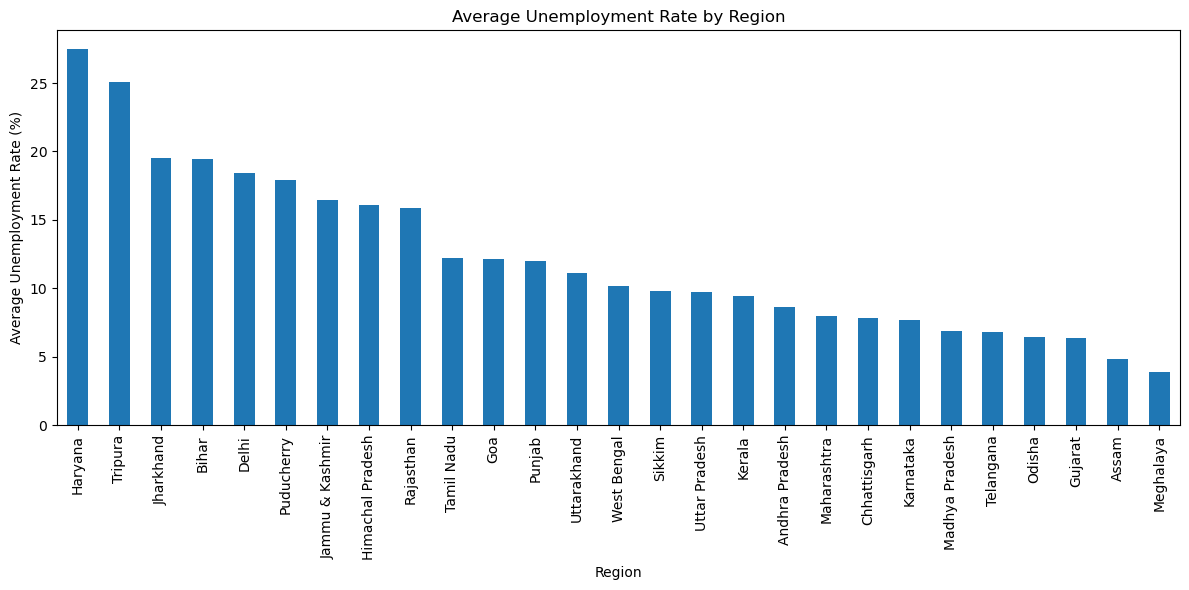

In [38]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation

#### The Region-Wise Analysis Shows That Unemployment Rates Vary Across Different Regions of India. Some Regions Have Considerably Higher Average Unemployment Rates Than Others, Indicating Differences In Employment Opportunities And Labour Market Conditions.

### 2.Month-wise Average Unemployment Rate

In [39]:
monthly_avg = df.groupby(df["Date"].dt.month)["Estimated Unemployment Rate (%)"].mean()

monthly_avg

Date
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64

### Month-wise Trend Chart

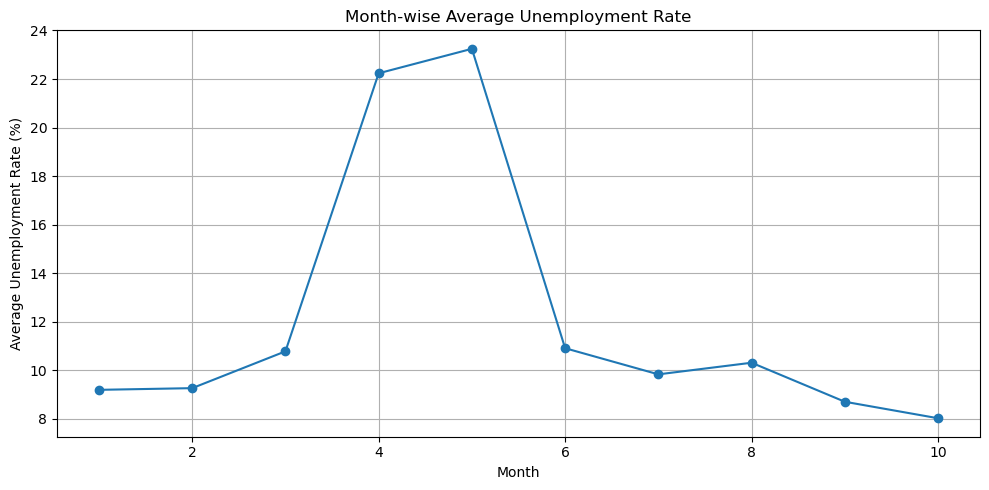

In [40]:
monthly_avg.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Month-wise Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

#### The Month-wise Analysis Shows That Unemployment Rates Vary Considerably Across the Available Months. The Unemployment Rate Increases sharply during April and May, while comparatively Lower Rates Are Observed During September and October.

## STEP 5 — Time-Series Analysis

In [41]:
df["Region"].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal'], dtype=object)

### Time-Series Chart

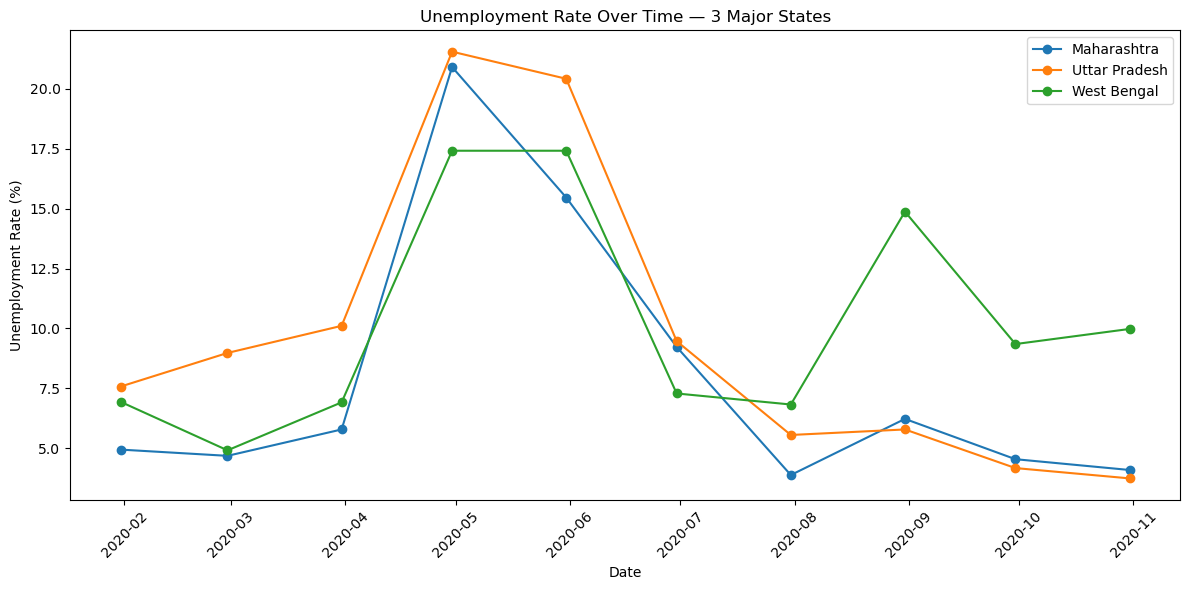

In [42]:
plt.figure(figsize=(12, 6))

for region in ["Maharashtra", "Uttar Pradesh", "West Bengal"]:
    region_data = df[df["Region"] == region]
    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time — 3 Major States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

#### The Time-Series Analysis shows that Unemployment Rates Fluctuate Over Time Across Maharashtra, Uttar Pradesh, and West Bengal. The Three states show different Unemployment Patterns, With Noticeable Changes During The Observed Period.

## STEP 6 — Top 10 Regions by Average Unemployment Rate

In [43]:
top_10_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10_regions

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

### Top 10 Regions — Bar Chart

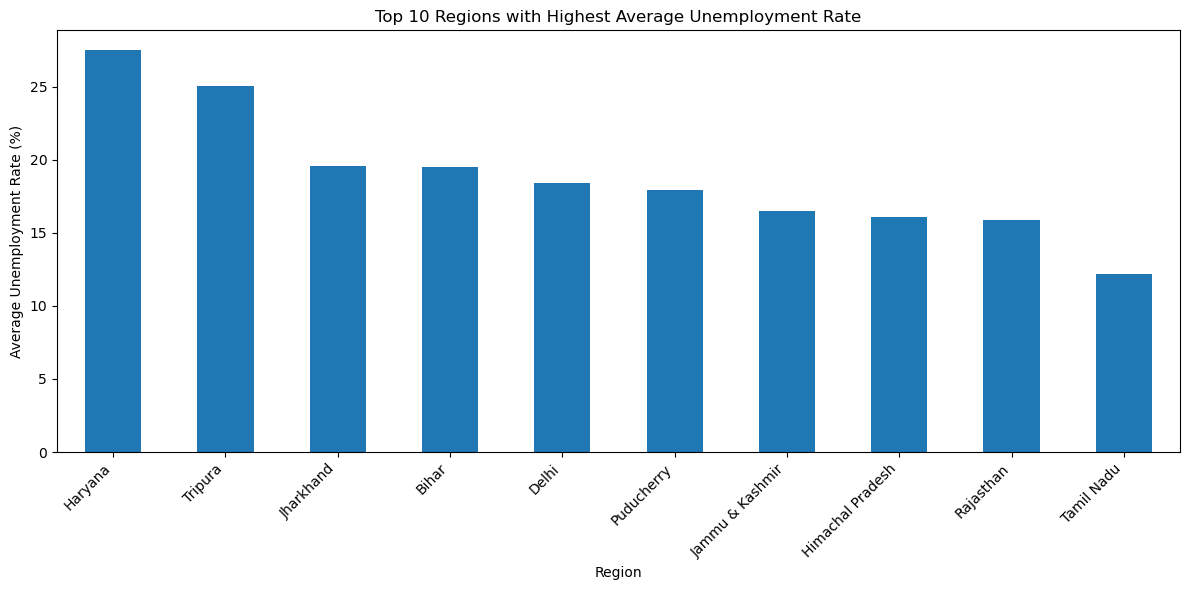

In [44]:
plt.figure(figsize=(12, 6))

top_10_regions.plot(kind="bar")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observation

#### The Top 10 Regions Show Noticeable Differences In Their Average Unemployment Rates. The Region With the Highest Average Unemployment Rate Experiences Comparatively Greater Unemployment Than the Other Regions in the Dataset.

## STEP 7 — Correlation Analysis & Heatmap

In [45]:
correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.245176,-0.073540
Estimated Employed,-0.245176,1.000000,-0.047948
Estimated Labour Participation Rate (%),-0.073540,-0.047948,1.000000


### Heatmap

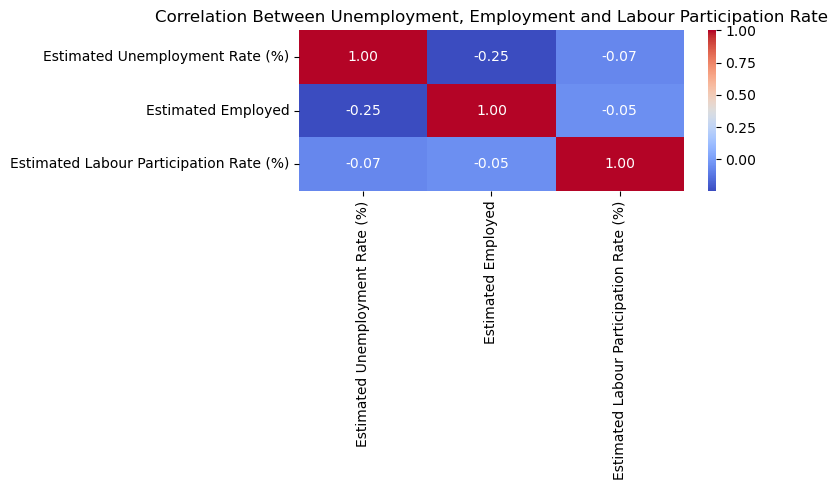

In [46]:
plt.figure(figsize=(8, 5))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Unemployment, Employment and Labour Participation Rate")
plt.tight_layout()
plt.show()

### Observation

#### The Heatmap Shows a Weak Negative Correlation Between The Unemployment Rate And Employment level (-0.25). The Correlation Between Unemployment Rate And Labour participation Rate Is Also Weak And Negative (-0.07). Overall, The Three Variables Do Not Show a Strong Linear Correlation In This Dataset.

## STEP 8 — Pre-COVID vs Post-COVID Comparison

### Create COVID Period

In [47]:
pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]

### Calculate Mean Rates

In [48]:
pre_covid_mean = pre_covid[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

post_covid_mean = post_covid[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

comparison = pd.DataFrame({
    "Pre-COVID": pre_covid_mean,
    "Post-COVID": post_covid_mean
})

comparison

,Pre-COVID,Post-COVID
Estimated Unemployment Rate (%),9.231346e+00,1.296386e+01
Estimated Employed,1.556273e+07,1.357498e+07
Estimated Labour Participation Rate (%),4.440365e+01,4.102321e+01


### Pre-COVID vs Post-COVID Chart

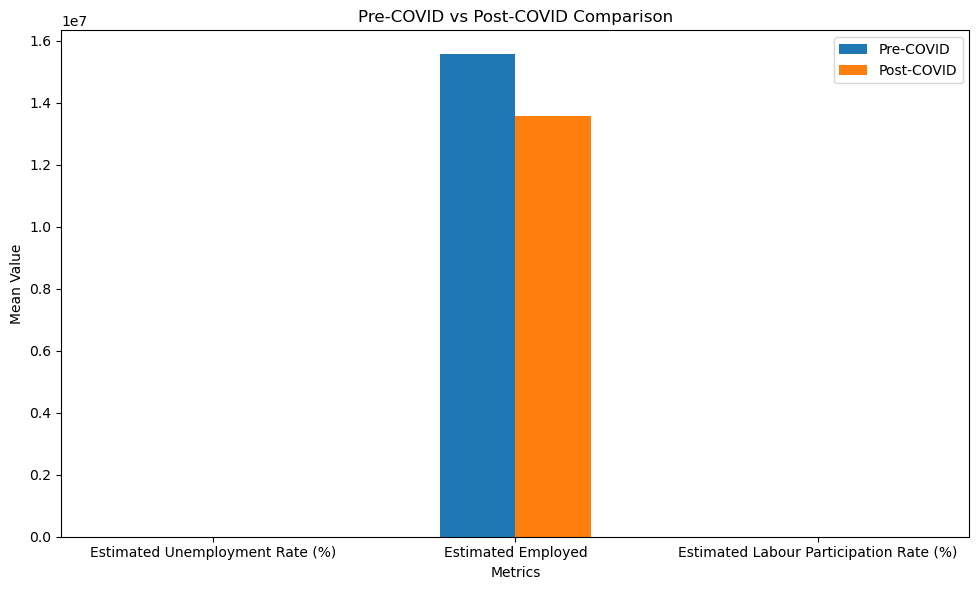

In [49]:
comparison.plot(kind="bar", figsize=(10, 6))

plt.title("Pre-COVID vs Post-COVID Comparison")
plt.xlabel("Metrics")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

#### The Comparison Shows a Clear Difference Between the Pre-COVID and Post-COVID periods.The Unemployment Rate Increased During The COVID-19 period, While the employment level and labour participation Rate Also Changed.This Indicates That The Pandemic Had a Noticeable impact on India's Labour Market.

## STEP 9 — COVID-19 Impact Analysis

In [50]:
covid_comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate (%)": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ]
})

covid_comparison

,Period,Average Unemployment Rate (%)
0,Pre-COVID,9.231346
1,Post-COVID,12.963860


## STEP 10 — Conclusion

## Conclusion

#### The Analysis Of Unemployment Data In India Revealed Important Regional and Temporal Patterns.

#### - Unemployment rates varied significantly across different regions.
#### - The Month-Wise Analysis Showed Considerable Changes In Unemployment Rates During The Observed Period.
#### - Maharashtra, Uttar Pradesh, and West Bengal showed Different Unemployment Trends Over Time.
#### - The Top 10 Regions Had noticeably Higher Average Unemployment Rates compared with Other Regions.
#### - The Correlation analysis Showed Weak Relationships Between Unemployment Rate, Employment Level, And Labour Participation Rate.
#### - The Comparison between Pre-COVID and Post-COVID periods showed a Noticeable Change In India's Labour Market Conditions.
#### - The Analysis Indicates That The COVID-19 Pandemic Had a Significant Impact on Unemployment And Employment Conditions in India.

#### Overall, Exploratory Data Analysis Helped Identify eRgional Differences, Temporal Trends, And the Impact of COVID-19 On Unemployment In India.